# Cascade Classifier Pipeline

Extracts crops from Mapillary + LISA, trains MobileNetV3-Small per superclass,
then evaluates the full detector + classifier pipeline.

**Fixes from previous version:**
- Class merges applied before crop extraction (g2/g3 variants folded into g1)
- LISA buffer classes included in the `other` category
- LISA crops sourced directly from `dataset/lisa/` instead of combined dataset
- Reduced augmentation — many crops are already low resolution

In [3]:
import csv
import json
import yaml
import time
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

from PIL import Image
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from ultralytics import YOLO

## Configuration

In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────────
MAPILLARY_ROOT  = Path("dataset/mtsd_v2_fully_annotated")
LISA_ROOT       = Path("dataset/lisa")                      # raw LISA YOLO dataset
COMBINED_ROOT   = Path("dataset/combined_dataset_640")    # for eval only
MAPILLARY_CSV   = Path("mapillary_class_review.csv")
LISA_CSV        = Path("lisa_review.csv")
CROPS_ROOT      = Path("dataset/classifier_crops")
MODELS_ROOT     = Path("experiments/classifiers")
DETECTOR_PATH   = "experiments/baseline_v3/weights/best.pt"

MODELS_ROOT.mkdir(parents=True, exist_ok=True)

# ── Crop extraction ───────────────────────────────────────────────────────────
CROP_PAD        = 0.20
MIN_CROP_PX     = 20
SPLITS          = ["train", "val", "test"]
LISA_SPLITS     = ["train", "val", "test"]   # adjust if your LISA uses "valid"

# ── Training ──────────────────────────────────────────────────────────────────
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE      = 64
EPOCHS          = 30
LR              = 3e-4
IMG_SIZE        = 224
SEED            = 42

random.seed(SEED)
torch.manual_seed(SEED)
print(f"Device: {DEVICE}")

# ── Class merges — same as dataset builder ────────────────────────────────────
# Variant labels (g2, g3) are folded into the canonical label (g1)
# so classifier training is consistent with detector training
MAPILLARY_MERGES = {
    "regulatory--no-turn-on-red--g1": [
        "regulatory--no-turn-on-red--g2",
        "regulatory--no-turn-on-red--g3",
    ],
    "warning--divided-highway-ends--g1": [
        "warning--divided-highway-ends--g2",
    ],
    "complementary--one-direction-left--g1": [
        "complementary--one-direction-right--g1",
    ],
    "warning--texts--g1": [
        "warning--texts--g2",
        "warning--texts--g3",
    ],
}

# Build variant → canonical lookup
MERGE_REMAP = {}
for canonical, variants in MAPILLARY_MERGES.items():
    for v in variants:
        MERGE_REMAP[v] = canonical
    MERGE_REMAP[canonical] = canonical   # canonical maps to itself

print(f"Merge remap covers {len(MERGE_REMAP)} labels")

# ── Load class names from combined dataset ────────────────────────────────────
with open(COMBINED_ROOT / "data.yaml") as f:
    data_yaml = yaml.safe_load(f)
id_to_label = {i: name for i, name in enumerate(data_yaml["names"])}
print(f"{len(id_to_label)} classes in combined dataset")

Device: cuda
Merge remap covers 10 labels
51 classes in combined dataset


## Step 1 — Superclass Taxonomy

In [5]:
# Maps canonical labels → superclass
# Merged variant labels automatically resolve to their canonical here
SUPERCLASS_MAP = {
    # Speed limit
    "regulatory--maximum-speed-limit-25--g2" : "speed_limit",
    "regulatory--maximum-speed-limit-30--g3" : "speed_limit",
    "regulatory--maximum-speed-limit-35--g2" : "speed_limit",
    "regulatory--maximum-speed-limit-40--g3" : "speed_limit",
    "regulatory--maximum-speed-limit-45--g3" : "speed_limit",
    "regulatory--maximum-speed-limit-55--g2" : "speed_limit",
    "regulatory--maximum-speed-limit-65--g2" : "speed_limit",
    # Warning
    "warning--curve-left--g2"                : "warning",
    "warning--curve-right--g2"               : "warning",
    "warning--turn-left--g1"                 : "warning",
    "warning--turn-right--g1"                : "warning",
    "warning--pedestrians-crossing--g4"      : "warning",
    "warning--children--g2"                  : "warning",
    "warning--school-zone--g2"               : "warning",
    "warning--traffic-signals--g3"           : "warning",
    "warning--added-lane-right--g1"          : "warning",
    "warning--road-narrows-right--g2"        : "warning",
    "warning--road-narrows-left--g2"         : "warning",
    "warning--crossroads--g3"                : "warning",
    "warning--divided-highway-ends--g1"      : "warning",   # canonical — g2 merges here
    "warning--double-curve-first-right--g2"  : "warning",
    "warning--stop-ahead--g9"                : "warning",
    "warning--traffic-merges-right--g1"      : "warning",
    "warning--slippery-road-surface--g2"     : "warning",
    "warning--railroad-crossing--g1"         : "warning",
    "warning--railroad-intersection--g3"     : "warning",
    "warning--texts--g1"                     : "warning",   # canonical — g2/g3 merge here
    # Regulatory
    "regulatory--stop--g1"                    : "regulatory",
    "regulatory--no-entry--g1"                : "regulatory",
    "regulatory--no-left-turn--g1"            : "regulatory",
    "regulatory--no-right-turn--g1"           : "regulatory",
    "regulatory--no-u-turn--g1"               : "regulatory",
    "regulatory--no-turn-on-red--g1"          : "regulatory",   # canonical — g2/g3 merge here
    "regulatory--no-parking--g2"              : "regulatory",
    "regulatory--yield--g1"                   : "regulatory",
    "regulatory--turn-left--g2"               : "regulatory",
    "regulatory--turn-right--g3"              : "regulatory",
    "regulatory--one-way-left--g2"            : "regulatory",
    "regulatory--one-way-right--g2"           : "regulatory",
    "regulatory--wrong-way--g1"               : "regulatory",
    "regulatory--keep-right--g4"              : "regulatory",
    "regulatory--keep-left--g2"               : "regulatory",
    "regulatory--lane-control--g1"            : "regulatory",
    "regulatory--reversible-lanes--g2"        : "regulatory",
    "regulatory--left-turn-yield-on-green--g1": "regulatory",
}

superclasses = sorted(set(SUPERCLASS_MAP.values()))
for sc in superclasses:
    n = sum(1 for s in SUPERCLASS_MAP.values() if s == sc)
    print(f"  {sc}: {n} classes")

  regulatory: 18 classes
  speed_limit: 7 classes


## Step 2 — Load Buffer Labels For `other` Class
Buffer classes from both Mapillary and LISA are included.

In [6]:
def load_mapillary_buffers(mapillary_csv, merge_remap):
    """
    Returns {canonical_label: superclass} for Mapillary buffer labels.
    Applies merge remap so variant buffers resolve to their canonical.
    """
    buffer = {}
    with open(mapillary_csv, newline="") as f:
        for row in csv.DictReader(f):
            if row["keep"] != "buffer":
                continue
            label = row["label"]
            # Apply merge remap if applicable
            label = merge_remap.get(label, label)
            # Skip if it became a kept class after merging
            if label in SUPERCLASS_MAP:
                continue
            if "maximum-speed" in label or "speed-limit" in label:
                buffer[label] = "speed_limit"
            elif label.startswith("warning--"):
                buffer[label] = "warning"
            elif label.startswith("regulatory--"):
                buffer[label] = "regulatory"
    return buffer


def load_lisa_buffers(lisa_csv, merge_remap):
    """
    Returns {mapillary_label: superclass} for LISA labels marked keep=buffer.
    Uses the mapillary_label column from the LISA review CSV.
    """
    buffer = {}
    with open(lisa_csv, newline="") as f:
        for row in csv.DictReader(f):
            if row["keep"] != "buffer":
                continue
            label = row["mapillary_label"].strip()
            if not label:
                continue
            # Apply merge remap
            label = merge_remap.get(label, label)
            if label in SUPERCLASS_MAP:
                continue
            if "maximum-speed" in label or "speed-limit" in label:
                buffer[label] = "speed_limit"
            elif label.startswith("warning--"):
                buffer[label] = "warning"
            elif label.startswith("regulatory--"):
                buffer[label] = "regulatory"
    return buffer


mply_buffers = load_mapillary_buffers(MAPILLARY_CSV, MERGE_REMAP)
lisa_buffers = load_lisa_buffers(LISA_CSV, MERGE_REMAP)

# Merge both buffer dicts
buffer_labels = {**mply_buffers, **lisa_buffers}

print(f"Mapillary buffer labels : {len(mply_buffers)}")
print(f"LISA buffer labels      : {len(lisa_buffers)}")
print(f"Total buffer labels     : {len(buffer_labels)}")
for sc in superclasses:
    n = sum(1 for s in buffer_labels.values() if s == sc)
    print(f"  {sc}_other: {n} buffer labels")

Mapillary buffer labels : 71
LISA buffer labels      : 0
Total buffer labels     : 71
  regulatory_other: 19 buffer labels
  speed_limit_other: 11 buffer labels
  warning_other: 41 buffer labels


## Step 3 — Extract Crops From Mapillary
Applies merge remap so variant annotations (g2, g3) are saved under the canonical class folder.

In [6]:
def padded_crop_coords(bbox_dict, img_w, img_h, pad):
    xmin, ymin = bbox_dict["xmin"], bbox_dict["ymin"]
    xmax, ymax = bbox_dict["xmax"], bbox_dict["ymax"]
    pw = (xmax - xmin) * pad
    ph = (ymax - ymin) * pad
    return (
        max(0,     xmin - pw), max(0,     ymin - ph),
        min(img_w, xmax + pw), min(img_h, ymax + ph),
    )


def extract_mapillary_crops(
        mapillary_root, superclass_map, buffer_labels,
        merge_remap, output_root, crop_pad, min_crop_px, seed):

    ann_dir    = mapillary_root / "annotations"
    img_dir    = mapillary_root / "images"
    splits_dir = mapillary_root / "splits"

    # Replicate split assignment from dataset builder
    key_to_split = {}
    for spl in ["train", "val"]:
        p = splits_dir / f"{spl}.txt"
        if p.exists():
            with open(p) as f:
                for line in f:
                    k = line.strip()
                    if k: key_to_split[k] = spl
    # Redirect empty test split to val
    test_p = splits_dir / "test.txt"
    if test_p.exists():
        with open(test_p) as f:
            for line in f:
                k = line.strip()
                if k: key_to_split[k] = "val"
    # Carve 10% of train as test
    train_keys = [k for k, s in key_to_split.items() if s == "train"]
    random.seed(seed)
    random.shuffle(train_keys)
    for k in train_keys[:int(len(train_keys) * 0.10)]:
        key_to_split[k] = "test"

    # Build lookup: raw_label -> (canonical_label, superclass, is_buffer)
    all_targets = {}
    for raw, canonical in merge_remap.items():
        if canonical in superclass_map:
            all_targets[raw] = (canonical, superclass_map[canonical], False)
    for raw_label, sc in buffer_labels.items():
        # Buffer labels may also need merge remap applied
        canonical = merge_remap.get(raw_label, raw_label)
        all_targets[raw_label] = (canonical, sc, True)
    # Also add kept labels that aren't in the merge remap
    for label, sc in superclass_map.items():
        if label not in all_targets:
            all_targets[label] = (label, sc, False)

    written = skipped = 0
    for ann_path in tqdm(list(ann_dir.glob("*.json")), desc="Mapillary"):
        key      = ann_path.stem
        split    = key_to_split.get(key, "train")
        img_path = img_dir / f"{key}.jpg"
        if not img_path.exists(): continue

        with open(ann_path) as f:
            ann = json.load(f)
        if ann.get("ispano", False): continue

        img_w = ann["width"]
        img_h = ann["height"]
        img   = None

        for i, obj in enumerate(ann.get("objects", [])):
            raw_label = obj.get("label", "")
            if raw_label not in all_targets: continue

            props = obj.get("properties", {})
            if props.get("ambiguous") or props.get("out-of-frame") or \
               props.get("dummy")     or props.get("occluded"): continue

            canonical, sc, is_buf = all_targets[raw_label]
            out_label = "other" if is_buf else canonical

            x1, y1, x2, y2 = padded_crop_coords(
                obj["bbox"], img_w, img_h, crop_pad)
            if (x2-x1) < min_crop_px or (y2-y1) < min_crop_px:
                skipped += 1; continue

            if img is None:
                img = Image.open(img_path).convert("RGB")

            out_dir = output_root / split / sc / out_label
            out_dir.mkdir(parents=True, exist_ok=True)
            img.crop((x1, y1, x2, y2)).save(
                out_dir / f"{key}_{i}.jpg", quality=92)
            written += 1

    print(f"  Written: {written:,}  |  Skipped (too small): {skipped:,}")


if CROPS_ROOT.exists():
    print(f"Clearing {CROPS_ROOT}...")
    shutil.rmtree(CROPS_ROOT)

print("Extracting Mapillary crops...")
extract_mapillary_crops(
    MAPILLARY_ROOT, SUPERCLASS_MAP, buffer_labels,
    MERGE_REMAP, CROPS_ROOT, CROP_PAD, MIN_CROP_PX, SEED)
print("Done.")

Extracting Mapillary crops...


Mapillary:   0%|          | 0/41909 [00:00<?, ?it/s]

  Written: 18,794  |  Skipped (too small): 539
Done.


## Step 4 — Extract Crops From LISA
Sources crops directly from `dataset/lisa/` using the LISA review CSV
to map LISA class IDs to canonical Mapillary labels (including merges).

In [7]:
def load_lisa_label_map(lisa_csv, lisa_root, merge_remap):
    """
    Builds {lisa_class_id: (canonical_mapillary_label, is_buffer)}
    from the LISA review CSV and data.yaml.
    """
    # Load LISA class id -> lisa_label from data.yaml
    with open(lisa_root / "data.yaml") as f:
        lisa_yaml = yaml.safe_load(f)
    names = lisa_yaml["names"]
    if isinstance(names, dict):
        lisa_id_to_name = {int(k): v for k, v in names.items()}
    else:
        lisa_id_to_name = {i: n for i, n in enumerate(names)}

    # Load LISA review CSV: lisa_label -> (mapillary_label, keep)
    lisa_name_to_mapillary = {}
    with open(lisa_csv, newline="") as f:
        for row in csv.DictReader(f):
            keep = row["keep"]
            if keep not in ("yes", "buffer"):
                continue
            lisa_name  = row["lisa_label"]
            mply_label = row["mapillary_label"].strip()
            if not mply_label:
                continue
            # Apply merge remap to get canonical
            canonical = merge_remap.get(mply_label, mply_label)
            lisa_name_to_mapillary[lisa_name] = (canonical, keep == "buffer")

    # Build final id -> (canonical, is_buffer) map
    result = {}
    for cls_id, lisa_name in lisa_id_to_name.items():
        if lisa_name in lisa_name_to_mapillary:
            result[cls_id] = lisa_name_to_mapillary[lisa_name]
    return result


def yolo_padded_crop(cx, cy, bw, bh, img_w, img_h, pad):
    xmin = (cx - bw/2) * img_w
    ymin = (cy - bh/2) * img_h
    xmax = (cx + bw/2) * img_w
    ymax = (cy + bh/2) * img_h
    pw = (xmax - xmin) * pad
    ph = (ymax - ymin) * pad
    return (
        max(0,     xmin - pw), max(0,     ymin - ph),
        min(img_w, xmax + pw), min(img_h, ymax + ph),
    )


def extract_lisa_crops(
        lisa_root, lisa_splits, lisa_label_map, superclass_map,
        output_root, crop_pad, min_crop_px):
    """
    Extracts crops from the raw LISA dataset.
    lisa_label_map: {lisa_class_id: (canonical_label, is_buffer)}
    """
    split_remap = {"train": "train", "valid": "val", "val": "val", "test": "test"}
    written = skipped = 0

    for split in lisa_splits:
        lbl_dir = lisa_root / split / "labels"
        img_dir = lisa_root / split / "images"
        split_out = split_remap.get(split, split)

        if not lbl_dir.exists():
            print(f"  [warn] not found: {lbl_dir}")
            continue

        for lbl_path in tqdm(list(lbl_dir.glob("*.txt")),
                             desc=f"LISA {split}"):
            img_path = None
            for ext in [".jpg", ".jpeg", ".png"]:
                c = img_dir / (lbl_path.stem + ext)
                if c.exists(): img_path = c; break
            if img_path is None: continue

            with open(lbl_path) as f:
                lines = [l.strip().split() for l in f if l.strip()]
            if not lines: continue

            img = None
            for i, parts in enumerate(lines):
                if len(parts) < 5: continue
                cls_id = int(parts[0])
                if cls_id not in lisa_label_map: continue

                canonical, is_buf = lisa_label_map[cls_id]
                # Determine superclass
                if canonical in superclass_map:
                    sc = superclass_map[canonical]
                elif is_buf:
                    # Buffer — find superclass from prefix
                    if "maximum-speed" in canonical:
                        sc = "speed_limit"
                    elif canonical.startswith("warning--"):
                        sc = "warning"
                    elif canonical.startswith("regulatory--"):
                        sc = "regulatory"
                    else:
                        continue
                else:
                    continue

                out_label = "other" if is_buf else canonical

                if img is None:
                    img = Image.open(img_path).convert("RGB")

                cx, cy, bw, bh = [float(x) for x in parts[1:5]]
                x1, y1, x2, y2 = yolo_padded_crop(
                    cx, cy, bw, bh, img.width, img.height, crop_pad)

                if (x2-x1) < min_crop_px or (y2-y1) < min_crop_px:
                    skipped += 1; continue

                out_dir = output_root / split_out / sc / out_label
                out_dir.mkdir(parents=True, exist_ok=True)
                img.crop((x1, y1, x2, y2)).save(
                    out_dir / f"lisa_{lbl_path.stem}_{i}.jpg", quality=92)
                written += 1

    print(f"  Written: {written:,}  |  Skipped (too small): {skipped:,}")


lisa_label_map = load_lisa_label_map(LISA_CSV, LISA_ROOT, MERGE_REMAP)
print(f"LISA label map: {len(lisa_label_map)} class IDs")

print("Extracting LISA crops...")
extract_lisa_crops(
    LISA_ROOT, LISA_SPLITS, lisa_label_map, SUPERCLASS_MAP,
    CROPS_ROOT, CROP_PAD, MIN_CROP_PX)
print("Done.")

LISA label map: 21 class IDs
Extracting LISA crops...


LISA train:   0%|          | 0/7956 [00:00<?, ?it/s]

LISA val:   0%|          | 0/1018 [00:00<?, ?it/s]

LISA test:   0%|          | 0/838 [00:00<?, ?it/s]

  Written: 5,462  |  Skipped (too small): 850
Done.


## Step 5 — Crop Distribution Summary

In [8]:
for split in SPLITS:
    split_dir = CROPS_ROOT / split
    if not split_dir.exists(): continue
    print(f"\n{'='*65}  Split: {split}  {'='*65}")
    for sc_dir in sorted(split_dir.iterdir()):
        if not sc_dir.is_dir(): continue
        print(f"\n  [{sc_dir.name}]")
        counts = {d.name: len(list(d.glob("*.jpg")))
                  for d in sorted(sc_dir.iterdir()) if d.is_dir()}
        for cls, n in sorted(counts.items(), key=lambda x: -x[1]):
            flag = "  ⚠️" if n < 50 else ""
            print(f"    {cls:<55} {n:>5,}{flag}")
        print(f"    {'─'*62}")
        print(f"    {'Total':<55} {sum(counts.values()):>5,}")


=================================================================  Split: train  =================================================================

  [regulatory]
    regulatory--yield--g1                                   1,822
    regulatory--no-entry--g1                                1,226
    regulatory--stop--g1                                      923
    other                                                     724
    regulatory--no-parking--g2                                381
    regulatory--keep-right--g4                                374
    regulatory--no-left-turn--g1                              363
    regulatory--no-u-turn--g1                                 339
    regulatory--no-right-turn--g1                             274
    regulatory--no-turn-on-red--g1                            190
    regulatory--turn-left--g2                                 162
    regulatory--one-way-left--g2                              102
    regulatory--keep-left--g2               

## Step 6 — Transforms

Augmentation is lighter than before because many crops are already
low resolution — aggressive augmentation on small crops degrades image
quality below what the classifier can use.

No horizontal or vertical flipping — flipping directional signs
(no-left-turn, one-way, curve-left) would create incorrect training examples.

In [7]:
def get_transforms(split):
    if split == "train":
        return transforms.Compose([
            transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
            transforms.RandomCrop(IMG_SIZE),
            transforms.RandomRotation(degrees=8),
            transforms.ColorJitter(
                brightness=0.3,
                contrast=0.3,
                saturation=0.2,
                hue=0.03,
            ),
            transforms.RandomPerspective(distortion_scale=0.15, p=0.2),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.03, 0.03),
                scale=(0.90, 1.10),
            ),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225]),
            transforms.RandomErasing(p=0.05, scale=(0.01, 0.05)),
        ])
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])


def build_dataloaders(superclass, crops_root, batch_size):
    loaders = {}; class_names = None
    for split in SPLITS:
        d = crops_root / split / superclass
        if not d.exists(): print(f"  [warn] missing: {d}"); continue
        ds = datasets.ImageFolder(root=str(d), transform=get_transforms(split))
        if class_names is None: class_names = ds.classes
        loaders[split] = DataLoader(
            ds, batch_size=batch_size,
            shuffle=(split=="train"),
            num_workers=4, pin_memory=True)
        print(f"  {split:<6}: {len(ds):>5,} crops  {len(ds.classes)} classes")
    return loaders, class_names


print("Transforms defined.")

Transforms defined.


## Step 7 — Train Classifiers

In [8]:
def build_model(num_classes, device):
    m   = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    inf = m.classifier[3].in_features
    m.classifier[3] = nn.Linear(inf, num_classes)
    return m.to(device)

In [10]:
def build_model(num_classes, device):
    m   = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    inf = m.classifier[3].in_features
    m.classifier[3] = nn.Linear(inf, num_classes)
    return m.to(device)


def train_classifier(superclass, crops_root, models_root,
                     epochs, lr, batch_size, device):
    print(f"\n{'='*60}\n  Training: {superclass}\n{'='*60}")
    loaders, class_names = build_dataloaders(superclass, crops_root, batch_size)
    if "train" not in loaders:
        print("  No training data — skipping."); return None, None

    print(f"  Classes ({len(class_names)}): {class_names}")
    model     = build_model(len(class_names), device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_acc  = 0.0
    best_path = models_root / f"{superclass}_best.pt"
    history   = {"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[]}

    for epoch in range(1, epochs+1):
        model.train()
        tl=tc=tt=0
        for imgs, labels in loaders["train"]:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs); loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            tl += loss.item()*imgs.size(0)
            tc += (out.argmax(1)==labels).sum().item()
            tt += imgs.size(0)
        scheduler.step()

        vl=vc=vt=0
        if "val" in loaders:
            model.eval()
            with torch.no_grad():
                for imgs, labels in loaders["val"]:
                    imgs, labels = imgs.to(device), labels.to(device)
                    out = model(imgs); loss = criterion(out, labels)
                    vl+=loss.item()*imgs.size(0)
                    vc+=(out.argmax(1)==labels).sum().item()
                    vt+=imgs.size(0)

        ta=tc/tt; va=vc/vt if vt else 0
        history["train_loss"].append(tl/tt)
        history["train_acc"].append(ta)
        history["val_loss"].append(vl/vt if vt else 0)
        history["val_acc"].append(va)

        if va > best_acc:
            best_acc = va
            torch.save({"model_state":model.state_dict(),
                        "class_names":class_names,
                        "superclass":superclass,
                        "model_name":"mobilenet_v3_small",
                        "img_size":IMG_SIZE}, best_path)

        if epoch%5==0 or epoch==epochs:
            print(f"  Epoch {epoch:3d}/{epochs}  "
                  f"train_acc={ta:.3f}  val_acc={va:.3f}  best={best_acc:.3f}")

    print(f"  Saved: {best_path}")
    return history, class_names


all_histories = {}
for sc in superclasses:
    hist, _ = train_classifier(
        sc, CROPS_ROOT, MODELS_ROOT, EPOCHS, LR, BATCH_SIZE, DEVICE)
    if hist: all_histories[sc] = hist


  Training: regulatory
  train : 7,415 crops  19 classes
  val   : 1,183 crops  19 classes
  test  :   869 crops  19 classes
  Classes (19): ['other', 'regulatory--keep-left--g2', 'regulatory--keep-right--g4', 'regulatory--lane-control--g1', 'regulatory--left-turn-yield-on-green--g1', 'regulatory--no-entry--g1', 'regulatory--no-left-turn--g1', 'regulatory--no-parking--g2', 'regulatory--no-right-turn--g1', 'regulatory--no-turn-on-red--g1', 'regulatory--no-u-turn--g1', 'regulatory--one-way-left--g2', 'regulatory--one-way-right--g2', 'regulatory--reversible-lanes--g2', 'regulatory--stop--g1', 'regulatory--turn-left--g2', 'regulatory--turn-right--g3', 'regulatory--wrong-way--g1', 'regulatory--yield--g1']
  Epoch   5/30  train_acc=0.990  val_acc=0.978  best=0.981
  Epoch  10/30  train_acc=0.997  val_acc=0.988  best=0.988
  Epoch  15/30  train_acc=0.999  val_acc=0.992  best=0.992
  Epoch  20/30  train_acc=1.000  val_acc=0.992  best=0.992
  Epoch  25/30  train_acc=0.999  val_acc=0.992  best=

## Step 8 — Training Curves

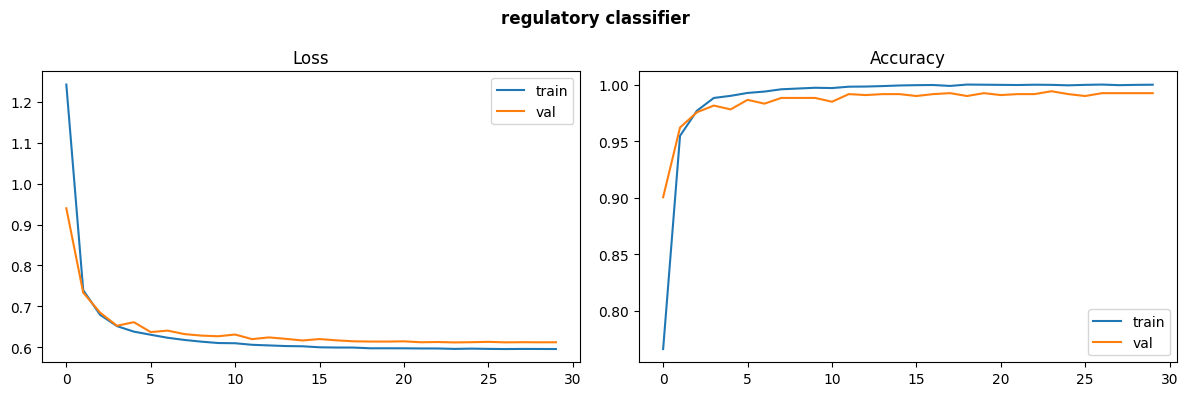

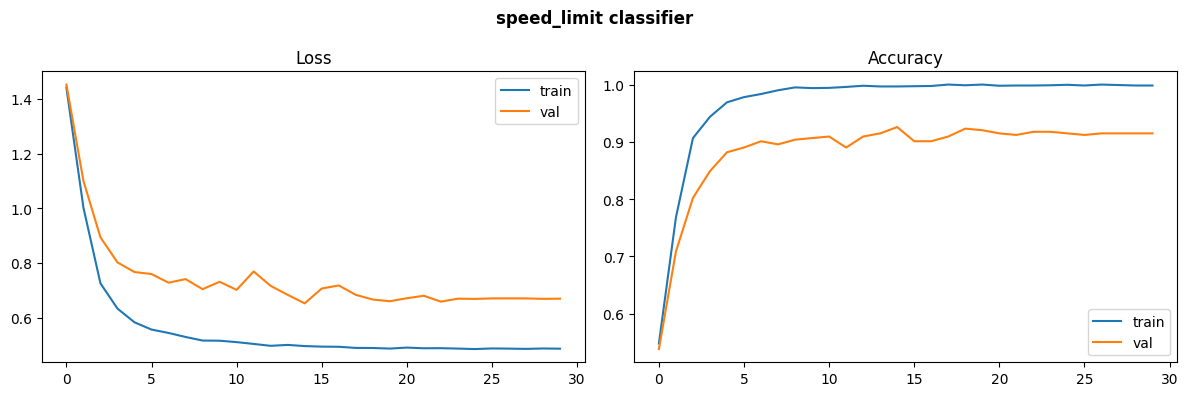

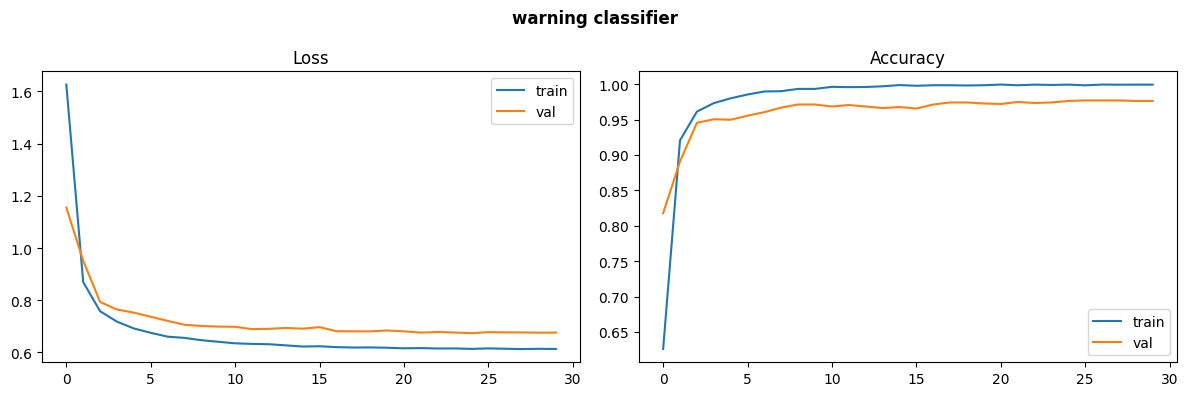

In [11]:
for sc, hist in all_histories.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{sc} classifier", fontweight="bold")
    ax1.plot(hist["train_loss"], label="train")
    ax1.plot(hist["val_loss"],   label="val")
    ax1.set_title("Loss"); ax1.legend()
    ax2.plot(hist["train_acc"], label="train")
    ax2.plot(hist["val_acc"],   label="val")
    ax2.set_title("Accuracy"); ax2.legend()
    plt.tight_layout()
    plt.savefig(MODELS_ROOT / f"{sc}_training_curve.png", dpi=100)
    plt.show()

## Step 9 — Per-Classifier Test Evaluation

In [10]:
classifiers, clf_class_names = load_all_classifiers(superclasses, MODELS_ROOT, DEVICE)

clf_tf = get_transforms("test")   # defined in Step 6 — run that cell first

def classify(crop_img, clf, names, device, threshold=0.30):
    t = clf_tf(crop_img).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.softmax(clf(t), dim=1)[0].cpu().numpy()
    idx = p.argmax(); conf = float(p[idx])
    return (names[idx], conf) if conf >= threshold else (None, 0.0)


def evaluate_pipeline(
        combined_root, detector_path, clfs, clf_names, id_to_label, device,
        split="test", det_conf=0.15, det_iou=0.45, clf_conf=0.30, crop_pad=0.20):

    detector = YOLO(detector_path)
    img_dir  = combined_root / split / "images"
    lbl_dir  = combined_root / split / "labels"
    det_ok   = defaultdict(int)
    cas_ok   = defaultdict(int)
    total    = defaultdict(int)

    for img_path in tqdm(list(img_dir.glob("*.jpg")), desc="Pipeline eval"):
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue

        gts = []
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    lbl = id_to_label.get(int(parts[0]))
                    if lbl:
                        lbl = MERGE_REMAP.get(lbl, lbl)
                        gts.append({"label": lbl,
                                    "cx": float(parts[1]),
                                    "cy": float(parts[2])})
                        total[lbl] += 1
        if not gts:
            continue

        img    = Image.open(img_path).convert("RGB")
        W, H   = img.size
        result = detector(str(img_path), conf=det_conf,
                          iou=det_iou, verbose=False)[0]
        if not len(result.boxes):
            continue

        boxes   = result.boxes.xyxy.cpu().numpy()
        cls_ids = result.boxes.cls.cpu().numpy().astype(int)

        for box, cls_id in zip(boxes, cls_ids):
            det_lbl = id_to_label.get(cls_id, "")
            if not det_lbl:
                continue
            det_lbl = MERGE_REMAP.get(det_lbl, det_lbl)

            x1, y1, x2, y2 = box
            pcx = ((x1+x2)/2) / W
            pcy = ((y1+y2)/2) / H

            best_gt = best_d = None
            for gt in gts:
                d = ((pcx-gt["cx"])**2 + (pcy-gt["cy"])**2)**0.5
                if best_d is None or d < best_d:
                    best_d, best_gt = d, gt
            if best_gt is None or best_d > 0.05:
                continue

            gt_lbl = best_gt["label"]
            if det_lbl == gt_lbl:
                det_ok[gt_lbl] += 1

            sc = route(det_lbl)
            if sc and sc in clfs:
                pw   = (x2-x1) * crop_pad
                ph   = (y2-y1) * crop_pad
                crop = img.crop((max(0, x1-pw), max(0, y1-ph),
                                 min(W, x2+pw), min(H, y2+ph)))
                clf_lbl, _ = classify(crop, clfs[sc], clf_names[sc],
                                      device, clf_conf)
                final = det_lbl if (clf_lbl is None or clf_lbl == "other") \
                        else clf_lbl
            else:
                final = det_lbl

            if final == gt_lbl:
                cas_ok[gt_lbl] += 1

    # ── Per-class results table ───────────────────────────────────────────────
    print(f"\n{'='*80}")
    print(f"  PIPELINE EVALUATION — {split}")
    print(f"{'='*80}")
    print(f"  {'Class':<53} {'GT':>5}  {'Det%':>6}  {'Casc%':>6}  {'Δ':>6}")
    print(f"  {'─'*77}")
    gd = gc = gs = 0
    for lbl in sorted(total):
        n  = total[lbl]
        dc = det_ok.get(lbl, 0)
        cc = cas_ok.get(lbl, 0)
        dp = 100*dc/n if n else 0
        cp = 100*cc/n if n else 0
        d  = cp - dp
        arrow = "  ↑" if d > 0 else ("  ↓" if d < 0 else "")
        print(f"  {lbl:<53} {n:>5}  {dp:>5.1f}%  {cp:>5.1f}%  {d:>+5.1f}{arrow}")
        gd += dc; gc += cc; gs += n
    print(f"  {'─'*77}")
    od = 100*gd/gs if gs else 0
    oc = 100*gc/gs if gs else 0
    print(f"  {'OVERALL':<53} {gs:>5}  {od:>5.1f}%  {oc:>5.1f}%  {oc-od:>+5.1f}")
    print(f"{'='*80}")

    # ── Superclass breakdown ──────────────────────────────────────────────────
    print(f"\n  IMPROVEMENT BY SUPERCLASS")
    print(f"  {'─'*60}")
    superclass_groups = {
        "speed_limit"  : [l for l in total if "maximum-speed-limit" in l],
        "warning"      : [l for l in total if l.startswith("warning--")],
        "regulatory"   : [l for l in total if l.startswith("regulatory--")
                          and "maximum-speed" not in l],
        "complementary": [l for l in total if l.startswith("complementary--")],
    }
    for group, labels in superclass_groups.items():
        g_gt  = sum(total[l]          for l in labels)
        g_det = sum(det_ok.get(l, 0)  for l in labels)
        g_cas = sum(cas_ok.get(l, 0)  for l in labels)
        if g_gt == 0:
            continue
        g_dp    = 100 * g_det / g_gt
        g_cp    = 100 * g_cas / g_gt
        has_clf = "✓ classifier" if group != "complementary" else "✗ no classifier"
        print(f"  {group:<20} {has_clf:<15}  GT={g_gt:>4}  "
              f"Det={g_dp:>5.1f}%  Casc={g_cp:>5.1f}%  Δ={g_cp-g_dp:>+5.1f}%")


evaluate_pipeline(
    COMBINED_ROOT, DETECTOR_PATH,
    classifiers, clf_class_names,
    id_to_label, DEVICE,
    split="test", det_conf=0.15, det_iou=0.45, clf_conf=0.30)

  regulatory: 19 classes
  speed_limit: 8 classes


Pipeline eval:   0%|          | 0/1624 [00:00<?, ?it/s]


  PIPELINE EVALUATION — test
  Class                                                    GT    Det%   Casc%       Δ
  ─────────────────────────────────────────────────────────────────────────────
  complementary--chevron-left--g1                         158   73.4%   73.4%   +0.0
  complementary--chevron-right--g1                        163   69.9%   69.9%   +0.0
  complementary--keep-left--g1                             31   74.2%   74.2%   +0.0
  complementary--keep-right--g1                            49   83.7%   83.7%   +0.0
  complementary--obstacle-delineator--g1                   14   71.4%   71.4%   +0.0
  complementary--obstacle-delineator--g2                   35   42.9%   42.9%   +0.0
  complementary--one-direction-left--g1                    15   26.7%   26.7%   +0.0
  regulatory--keep-left--g2                                13   76.9%   76.9%   +0.0
  regulatory--keep-right--g4                               55   50.9%   50.9%   +0.0
  regulatory--lane-control--g1         

## Step 10 — End-to-End Pipeline Evaluation

In [1]:
def load_all_classifiers(superclasses, models_root, device):
    clfs={}; clf_names={}
    for sc in superclasses:
        p = models_root / f"{sc}_best.pt"
        if not p.exists(): continue
        ckpt = torch.load(p, map_location=device, weights_only=False)
        m    = build_model(len(ckpt["class_names"]), device)
        m.load_state_dict(ckpt["model_state"]); m.eval()
        clfs[sc]=m; clf_names[sc]=ckpt["class_names"]
        print(f"  {sc}: {len(ckpt['class_names'])} classes")
    return clfs, clf_names


def route(label):
    if "maximum-speed-limit" in label: return "speed_limit"
    p = label.split("--")[0]
    if p=="warning"    and label in SUPERCLASS_MAP: return "warning"
    if p=="regulatory" and label in SUPERCLASS_MAP: return "regulatory"
    return None


clf_tf = get_transforms("test")

def classify(crop_img, clf, names, device, threshold=0.30):
    t = clf_tf(crop_img).unsqueeze(0).to(device)
    with torch.no_grad():
        p = torch.softmax(clf(t), dim=1)[0].cpu().numpy()
    idx=p.argmax(); conf=float(p[idx])
    return (names[idx], conf) if conf>=threshold else (None, 0.0)


def evaluate_pipeline(
        combined_root, detector_path, clfs, clf_names, id_to_label, device,
        split="test", det_conf=0.15, det_iou=0.45, clf_conf=0.30, crop_pad=0.20):

    detector  = YOLO(detector_path)
    img_dir   = combined_root / split / "images"
    lbl_dir   = combined_root / split / "labels"
    det_ok=defaultdict(int); cas_ok=defaultdict(int); total=defaultdict(int)

    for img_path in tqdm(list(img_dir.glob("*.jpg")), desc="Pipeline eval"):
        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists(): continue

        gts=[]
        with open(lbl_path) as f:
            for line in f:
                parts=line.strip().split()
                if len(parts)>=5:
                    lbl=id_to_label.get(int(parts[0]))
                    if lbl:
                        # Apply merge remap for fair comparison
                        lbl = MERGE_REMAP.get(lbl, lbl)
                        gts.append({"label":lbl,
                                    "cx":float(parts[1]),
                                    "cy":float(parts[2])})
                        total[lbl]+=1
        if not gts: continue

        img=Image.open(img_path).convert("RGB")
        W,H=img.size
        result=detector(str(img_path), conf=det_conf, iou=det_iou, verbose=False)[0]
        if not len(result.boxes): continue

        boxes=result.boxes.xyxy.cpu().numpy()
        cls_ids=result.boxes.cls.cpu().numpy().astype(int)

        for box, cls_id in zip(boxes, cls_ids):
            det_lbl=id_to_label.get(cls_id,"")
            if not det_lbl: continue
            det_lbl = MERGE_REMAP.get(det_lbl, det_lbl)

            x1,y1,x2,y2=box
            pcx=((x1+x2)/2)/W; pcy=((y1+y2)/2)/H

            best_gt=best_d=None
            for gt in gts:
                d=((pcx-gt["cx"])**2+(pcy-gt["cy"])**2)**0.5
                if best_d is None or d<best_d: best_d,best_gt=d,gt
            if best_gt is None or best_d>0.05: continue

            gt_lbl=best_gt["label"]
            if det_lbl==gt_lbl: det_ok[gt_lbl]+=1

            sc=route(det_lbl)
            if sc and sc in clfs:
                pw=(x2-x1)*crop_pad; ph=(y2-y1)*crop_pad
                crop=img.crop((max(0,x1-pw),max(0,y1-ph),
                               min(W,x2+pw),min(H,y2+ph)))
                clf_lbl,_=classify(crop,clfs[sc],clf_names[sc],device,clf_conf)
                final=det_lbl if (clf_lbl is None or clf_lbl=="other") else clf_lbl
            else:
                final=det_lbl

            if final==gt_lbl: cas_ok[gt_lbl]+=1
            
            print(f"\n  IMPROVEMENT BY SUPERCLASS")
            print(f"  {'─'*50}")

            superclass_groups = {
                "speed_limit"  : [l for l in total if "maximum-speed-limit" in l],
                "warning"      : [l for l in total if l.startswith("warning--")],
                "regulatory"   : [l for l in total if l.startswith("regulatory--")
                                and "maximum-speed" not in l],
                "complementary": [l for l in total if l.startswith("complementary--")],
            }

            for group, labels in superclass_groups.items():
                g_gt = sum(total[l] for l in labels)
                g_det = sum(det_ok.get(l, 0) for l in labels)
                g_cas = sum(cas_ok.get(l, 0) for l in labels)
                if g_gt == 0: continue
                g_dp = 100 * g_det / g_gt
                g_cp = 100 * g_cas / g_gt
                has_clf = "✓" if group != "complementary" else "✗"
                print(f"  {group:<20} {has_clf}  GT={g_gt:>4}  "
                    f"Det={g_dp:>5.1f}%  Casc={g_cp:>5.1f}%  Δ={g_cp-g_dp:>+5.1f}%")

                print(f"\n{'='*80}")
                print(f"  PIPELINE EVALUATION — {split}")
                print(f"{'='*80}")
                print(f"  {'Class':<53} {'GT':>5}  {'Det%':>6}  {'Casc%':>6}  {'Δ':>6}")
                print(f"  {'─'*77}")
                gd=gc=gs=0
                for lbl in sorted(total):
                    n=total[lbl]; dc=det_ok.get(lbl,0); cc=cas_ok.get(lbl,0)
                    dp=100*dc/n if n else 0; cp=100*cc/n if n else 0; d=cp-dp
                    arrow="  ↑" if d>0 else("  ↓" if d<0 else "")
                    print(f"  {lbl:<53} {n:>5}  {dp:>5.1f}%  {cp:>5.1f}%  {d:>+5.1f}{arrow}")
                    gd+=dc; gc+=cc; gs+=n
                print(f"  {'─'*77}")
                od=100*gd/gs if gs else 0; oc=100*gc/gs if gs else 0
                print(f"  {'OVERALL':<53} {gs:>5}  {od:>5.1f}%  {oc:>5.1f}%  {oc-od:>+5.1f}")
                print(f"{'='*80}")


classifiers, clf_class_names = load_all_classifiers(superclasses, MODELS_ROOT, DEVICE)
evaluate_pipeline(
    COMBINED_ROOT, DETECTOR_PATH,
    classifiers, clf_class_names,
    id_to_label, DEVICE,
    split="test", det_conf=0.15, det_iou=0.45, clf_conf=0.30)

NameError: name 'get_transforms' is not defined

## Step 11 — Classifier Inference Speed

In [11]:
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
print("Classifier inference speed (single crop):")
for sc, clf in classifiers.items():
    for _ in range(20):
        with torch.no_grad(): clf(dummy)
    if DEVICE=="cuda": torch.cuda.synchronize()
    times=[]
    for _ in range(300):
        t0=time.perf_counter()
        with torch.no_grad(): clf(dummy)
        if DEVICE=="cuda": torch.cuda.synchronize()
        times.append((time.perf_counter()-t0)*1000)
    t=np.array(times)
    print(f"  {sc:<20}  mean={t.mean():.2f}ms  "
          f"median={np.median(t):.2f}ms  p95={np.percentile(t,95):.2f}ms")

Classifier inference speed (single crop):
  regulatory            mean=3.90ms  median=3.72ms  p95=4.58ms
  speed_limit           mean=3.99ms  median=3.74ms  p95=5.83ms
  warning               mean=3.87ms  median=3.71ms  p95=5.19ms


### Generate assets for Android deployment (class labels json file, export to onnx)

In [2]:
import json
from pathlib import Path
import torch

MODELS_ROOT = Path("experiments/classifiers")
OUTPUT_DIR  = Path("experiments/classifiers/android_assets")
OUTPUT_DIR.mkdir(exist_ok=True)

superclasses = ["regulatory", "speed_limit", "warning"]

# ── Generate class maps from saved checkpoints ────────────────────────────────
all_class_maps = {}

for sc in superclasses:
    path = MODELS_ROOT / f"{sc}_best.pt"
    if not path.exists():
        print(f"[warn] no model for {sc}")
        continue
    ckpt   = torch.load(path, map_location="cpu", weights_only=False)
    names  = ckpt["class_names"]   # list ordered by class index
    all_class_maps[sc] = names
    print(f"  {sc}: {len(names)} classes")
    for i, name in enumerate(names):
        print(f"    {i:2d}  {name}")
    print()

# ── Save as JSON ──────────────────────────────────────────────────────────────
output = {
    "classifiers": {
        sc: {"classes": names}
        for sc, names in all_class_maps.items()
    },
    # Routing rules — which labels go to which classifier
    "routing": {
        "speed_limit": {
            "rule": "contains",
            "value": "maximum-speed-limit"
        },
        "warning": {
            "rule": "prefix",
            "value": "warning--"
        },
        "regulatory": {
            "rule": "prefix",
            "value": "regulatory--",
            "exclude_contains": "maximum-speed-limit"
        },
    }
}

out_path = OUTPUT_DIR / "classifier_config.json"
with open(out_path, "w") as f:
    json.dump(output, f, indent=2)
print(f"Saved to {out_path}")

# ── Also save flat class lists as separate files ──────────────────────────────
# Some Android developers prefer one file per classifier
for sc, names in all_class_maps.items():
    p = OUTPUT_DIR / f"{sc}_classes.txt"
    with open(p, "w") as f:
        for name in names:
            f.write(name + "\n")
    print(f"Saved {p}")

  regulatory: 19 classes
     0  other
     1  regulatory--keep-left--g2
     2  regulatory--keep-right--g4
     3  regulatory--lane-control--g1
     4  regulatory--left-turn-yield-on-green--g1
     5  regulatory--no-entry--g1
     6  regulatory--no-left-turn--g1
     7  regulatory--no-parking--g2
     8  regulatory--no-right-turn--g1
     9  regulatory--no-turn-on-red--g1
    10  regulatory--no-u-turn--g1
    11  regulatory--one-way-left--g2
    12  regulatory--one-way-right--g2
    13  regulatory--reversible-lanes--g2
    14  regulatory--stop--g1
    15  regulatory--turn-left--g2
    16  regulatory--turn-right--g3
    17  regulatory--wrong-way--g1
    18  regulatory--yield--g1

  speed_limit: 8 classes
     0  other
     1  regulatory--maximum-speed-limit-25--g2
     2  regulatory--maximum-speed-limit-30--g3
     3  regulatory--maximum-speed-limit-35--g2
     4  regulatory--maximum-speed-limit-40--g3
     5  regulatory--maximum-speed-limit-45--g3
     6  regulatory--maximum-speed-lim

In [6]:
import onnx
from onnx.external_data_helper import convert_model_to_external_data
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small
from pathlib import Path

MODELS_ROOT = Path("experiments/classifiers")
IMG_SIZE    = 224

def build_model(num_classes):
    m   = mobilenet_v3_small(weights=None)
    inf = m.classifier[3].in_features
    m.classifier[3] = nn.Linear(inf, num_classes)
    return m

for sc in ["regulatory", "speed_limit", "warning"]:
    pt_path   = MODELS_ROOT / f"{sc}_best.pt"
    onnx_path = MODELS_ROOT / f"{sc}_classifier.onnx"

    if not pt_path.exists():
        print(f"[warn] not found: {pt_path}")
        continue

    ckpt  = torch.load(pt_path, map_location="cpu", weights_only=False)
    names = ckpt["class_names"]
    model = build_model(len(names))
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

    # Export with all weights embedded in the single .onnx file
    torch.onnx.export(
        model,
        dummy,
        onnx_path,
        input_names   = ["input"],
        output_names  = ["output"],
        dynamic_axes  = None,
        opset_version = 17,
    )

    # Load and re-save with weights inlined — removes the .data file
    model_proto = onnx.load(str(onnx_path))
    onnx.save_model(
        model_proto,
        str(onnx_path),
        save_as_external_data = False,  # embed everything inline
    )

    size_mb = onnx_path.stat().st_size / 1e6
    print(f"  {sc}: {onnx_path.name}  ({size_mb:.1f} MB)  {len(names)} classes")

print("Done.")

W0326 18:08:37.900000 377864 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0326 18:08:38.198000 377864 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0326 18:08:38.199000 377864 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[in

[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


C:\Users\joneh\AppData\Local\Programs\Python\Python311\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Projects\TrafficSignRecognition\model_training\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Projects\TrafficSignRecognition\model_training\.venv\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 68 of general pattern rewrite rules.


W0326 18:08:39.534000 377864 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


...

Applied 68 of general pattern rewrite rules.
  speed_limit: speed_limit_classifier.onnx  (6.4 MB)  8 classes


W0326 18:08:41.633000 377864 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0326 18:08:41.635000 377864 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0326 18:08:41.636000 377864 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0326 18:08:41.637000 377864 Lib\site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[in

[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


C:\Users\joneh\AppData\Local\Programs\Python\Python311\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Projects\TrafficSignRecognition\model_training\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Projects\TrafficSignRecognition\model_training\.venv\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 68 of general pattern rewrite rules.
Done.
